# AAI Runs Analysis

Trend & framework-comparison analysis across every `*_debug_compare/` run in this `runs/` directory.

**Frameworks compared**

- `Single Shot` (mode=`single_prompt`)
- `Critic Off` (mode=`multi_agent`, used_critic=False)
- `Critic On` (mode=`multi_agent`, used_critic=True)

**Conventions**

- All ingestion logic lives in [aai_loader.py](aai_loader.py) so this notebook stays focused on analysis.
- The three primary DataFrames (`runs_df`, `stages_df`, `questions_df`) are treated as **immutable**. Every filter / transformation in this notebook calls `.copy()` so the originals are never mutated. Follow the same pattern when adding new cells.
- `RUNS_DIR` (set in the next cell) points at a *parent* folder. The loader walks it and ingests **every** `*_debug_compare/` subfolder it finds &mdash; so all runs are loaded together and every comparison in this notebook (trend chart, deltas, summaries) operates across the full set. Point `RUNS_DIR` at a different parent folder only if you want to analyze a different batch of runs.

## 1. Setup &mdash; imports and configuration

In [1]:
from __future__ import annotations

from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

from aai_loader import FRAMEWORK_COLORS, FRAMEWORK_ORDER, load_all

# --- Configuration ----------------------------------------------------------
RUNS_DIR = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path.cwd().parent
EXPORT_CSV = True            # write normalized DataFrames to analysis/exports/
EXPORTS_DIR = Path.cwd() / "exports"

# Name of the repository these AAI runs analyzed. Used as the value stamped
# into the `repo` column of every DataFrame, in plot titles, and in export
# filenames so slides and CSVs are self-describing.
REPO_NAME: str = "MovieHub"

# Plot defaults
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)


def title(text: str) -> str:
    """Prefix a plot/table title with the repo name for clearer slide naming."""
    return f"[{REPO_NAME}] {text}" if REPO_NAME else text


print(f"REPO_NAME = {REPO_NAME}")


REPO_NAME = MovieHub


## 2. Load runs

`load_all` parses every per-folder `debug_analysis.json` and returns three DataFrames.

In [2]:
runs_df, stages_df, questions_df = load_all(RUNS_DIR, repo_name=REPO_NAME)

print(f"runs_df:          {runs_df.shape}  (rows = run_folder x framework)")
print(f"stages_df:        {stages_df.shape}")
print(f"questions_df:     {questions_df.shape}")
print()
print("Frameworks present:", sorted(runs_df['framework'].unique()))
print("Run folders:       ", runs_df['run_id'].nunique())
print(f"REPO_NAME:         {REPO_NAME}")
runs_df.head()


runs_df:          (84, 17)  (rows = run_folder x framework)
stages_df:        (336, 9)
questions_df:     (1428, 10)

Frameworks present: ['Critic Off', 'Critic On', 'Single Shot']
Run folders:        28
REPO_NAME:         MovieHub


,repo,run_id,generated_at,framework,label,mode,used_critic,overall_score,core_overall_score,total_duration_seconds,input_tokens,output_tokens,total_tokens,n_questions,n_core_questions,n_variation_questions,summary
0,MovieHub,20260421_002501_debug_compare,2026-04-21 00:28:46,Critic Off,Multi-Agent Critic Off,multi_agent,False,57.65,97.142857,24.857,21491,1873,23364,17,7,10,"The diagram provides a high-level overview of the system's architecture, accurately capturing the main subsystems, r..."
1,MovieHub,20260421_002501_debug_compare,2026-04-21 00:28:46,Critic On,Multi-Agent Critic On,multi_agent,True,57.65,97.142857,46.851,30829,3463,34292,17,7,10,"The diagram provides a high-level overview of the system's architecture, accurately identifying the main subsystems,..."
2,MovieHub,20260421_002501_debug_compare,2026-04-21 00:28:46,Single Shot,Single Shot,single_prompt,False,51.76,91.428571,8.620,2973,511,3484,17,7,10,"The diagram provides a high-level overview of the system, accurately identifying the main subsystems, runtime bounda..."
3,MovieHub,20260421_003008_debug_compare,2026-04-21 00:33:58,Critic Off,Multi-Agent Critic Off,multi_agent,False,54.12,97.142857,26.523,21543,1879,23422,17,7,10,"The diagram provides a high-level overview of the system's architecture, accurately identifying the main subsystems,..."
4,MovieHub,20260421_003008_debug_compare,2026-04-21 00:33:58,Critic On,Multi-Agent Critic On,multi_agent,True,58.82,97.142857,49.998,30903,3621,34524,17,7,10,"The diagram provides a high-level overview of the system, accurately capturing the main subsystems, runtime boundari..."


In [3]:
# Sanity check: every (run_id, framework) should have exactly the documented core
# question count. The 7 documented core questions appear at the start of each run.
core_counts = (
    questions_df[questions_df["is_core"]]
    .groupby(["run_id", "framework"], as_index=False)
    .size()
    .rename(columns={"size": "n_core"})
)
assert (core_counts["n_core"] == 7).all(), core_counts[core_counts["n_core"] != 7]
print("OK: every (run_id, framework) has 7 core questions.")

OK: every (run_id, framework) has 7 core questions.


In [8]:
if EXPORT_CSV:
    assert REPO_NAME, "Set REPO_NAME in the setup cell before exporting."
    EXPORTS_DIR.mkdir(exist_ok=True)
    # Prefix every export with REPO_NAME so files from different repos don't
    # collide when collected together. The `repo` column is already stamped
    # by load_all().
    runs_df.to_csv(EXPORTS_DIR / f"{REPO_NAME}__runs.csv", index=False)
    stages_df.to_csv(EXPORTS_DIR / f"{REPO_NAME}__stages.csv", index=False)
    questions_df.to_csv(EXPORTS_DIR / f"{REPO_NAME}__questions.csv", index=False)
    #UNCOMMENT THE LINE BELOW TO ENABLE PRINTING
    # print(f"Wrote {REPO_NAME}__(runs|stages|questions).csv to {EXPORTS_DIR}")


## 3. Reusable filtering recipes

The three normalized DataFrames are treated as immutable. Every filter / transformation below ends with `.copy()` so the originals are preserved &mdash; please follow this convention when adding new cells.

In [9]:
# Filter by framework
critic_on_runs = runs_df.query("framework == 'Critic On'").copy()
critic_off_runs = runs_df.query("framework == 'Critic Off'").copy()
single_shot_runs = runs_df.query("framework == 'Single Shot'").copy()

# Core-only / variation-only question slices
core_questions_df = questions_df[questions_df["is_core"]].copy()
variation_questions_df = questions_df[~questions_df["is_core"]].copy()

# Filter stages_df by stage substring
draft_stages = stages_df[stages_df["stage"].str.contains("draft", na=False)].copy()

print(f"critic_on_runs:        {len(critic_on_runs)}")
print(f"critic_off_runs:       {len(critic_off_runs)}")
print(f"single_shot_runs:      {len(single_shot_runs)}")
print(f"core_questions_df:     {len(core_questions_df)}")
print(f"variation_questions_df:{len(variation_questions_df)}")
print(f"draft_stages:          {len(draft_stages)}")

critic_on_runs:        28
critic_off_runs:       28
single_shot_runs:      28
core_questions_df:     588
variation_questions_df:840
draft_stages:          84


## 4. Framework score comparison &mdash; core vs cumulative

How do Single Shot, Critic Off, and Critic On compare on the **core** 7 questions vs the **cumulative** (all-questions) score?

In [10]:
# Per-framework summary table for core, overall, and the (overall - core) delta.
score_summary = (
    runs_df.assign(overall_minus_core=runs_df["overall_score"] - runs_df["core_overall_score"])
    .groupby("framework")[["core_overall_score", "overall_score", "overall_minus_core"]]
    .agg(["mean", "median", "std", "min", "max", "count"])
    .round(2)
    .reindex(FRAMEWORK_ORDER)
)
score_summary

core_overall_score                                  overall_score                                  overall_minus_core                             \
                          mean median   std    min    max count          mean median   std    min    max count               mean median   std    min    max   
framework                                                                                                                                                      
Single Shot              93.06  91.43  2.74  88.57  97.14    28         58.57  58.82  5.15  48.24  70.59    28             -34.49 -33.70  4.60 -44.20 -26.55   
Critic Off               96.63  97.14  1.36  91.43  97.14    28         58.28  58.82  5.62  40.00  70.59    28             -38.36 -38.32  5.74 -57.14 -26.55   
Critic On                96.43  97.14  1.67  91.43  97.14    28         62.60  60.59  9.00  48.24  88.24    28             -33.82 -34.54  8.69 -45.38  -8.90   

                   
            count  
framework          
Single Shot    28  
Critic Off     28  
Critic On      28

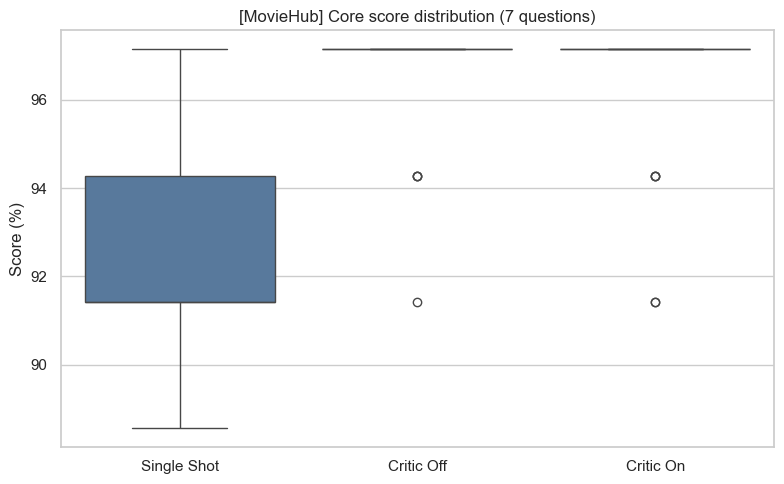

In [25]:
# Static: box plot of core scores by framework.
score_long = runs_df.melt(
    id_vars=["run_id", "framework", "generated_at"],
    value_vars=["core_overall_score", "overall_score"],
    var_name="score_kind",
    value_name="score",
).copy()
score_long["score_kind"] = score_long["score_kind"].map(
    {"core_overall_score": "Core (7 questions)", "overall_score": "Cumulative (all questions)"}
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=score_long[score_long["score_kind"] == "Core (7 questions)"],
    x="framework",
    y="score",
    hue="framework",
    order=FRAMEWORK_ORDER,
    palette=FRAMEWORK_COLORS,
    ax=ax,
)
ax.set_title(title("Core score distribution (7 questions)"))
ax.set_xlabel("")
ax.set_ylabel("Score (%)")
plt.tight_layout()
plt.show()


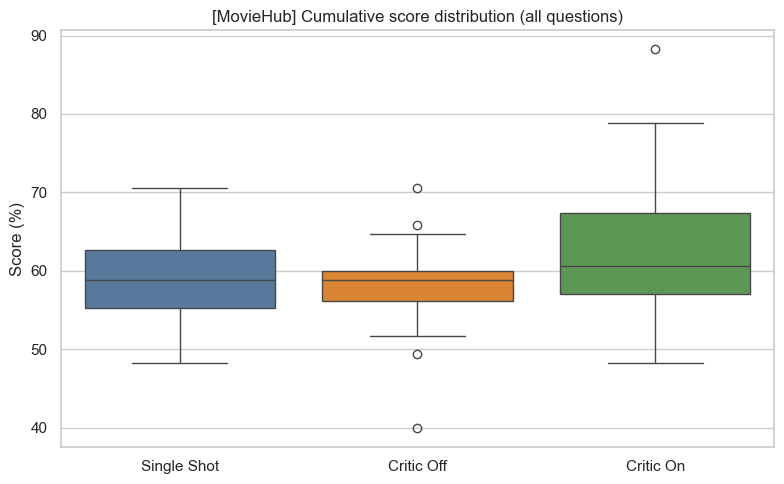

In [26]:
# Static: box plot of cumulative scores by framework.
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=score_long[score_long["score_kind"] == "Cumulative (all questions)"],
    x="framework",
    y="score",
    hue="framework",
    order=FRAMEWORK_ORDER,
    palette=FRAMEWORK_COLORS,
    ax=ax,
)
ax.set_title(title("Cumulative score distribution (all questions)"))
ax.set_xlabel("")
ax.set_ylabel("Score (%)")
plt.tight_layout()
plt.show()


In [13]:
# Interactive: plotly grouped box, hover shows run_id.
fig = px.box(
    score_long,
    x="score_kind",
    y="score",
    color="framework",
    category_orders={"framework": FRAMEWORK_ORDER, "score_kind": ["Core (7 questions)", "Cumulative (all questions)"]},
    color_discrete_map=FRAMEWORK_COLORS,
    points="all",
    hover_data=["run_id", "generated_at"],
    title=title("Score by framework (interactive)"),
)
fig.update_layout(yaxis_title="Score (%)", xaxis_title="", height=500)
fig.show()

## 5. Per-question deep-dive on the 7 core questions

Heatmap of mean score by core question x framework &mdash; identifies which fixed questions consistently fail.

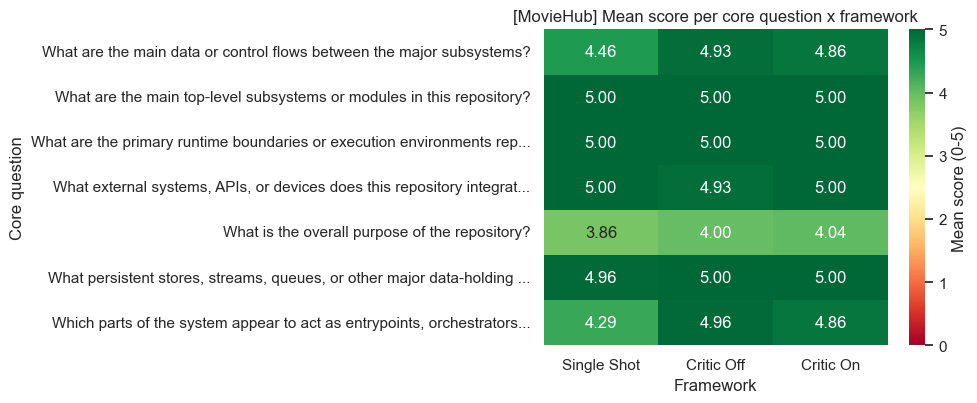

In [16]:
# Truncate long question text for axis labels.
def _short(text: str, n: int = 70) -> str:
    text = text.strip().replace("\n", " ")
    return text if len(text) <= n else text[: n - 1] + "..."

core_only = questions_df[questions_df["is_core"]].copy()
core_only["question_short"] = core_only["question"].map(_short)

heat_df = (
    core_only.groupby(["question_short", "framework"], as_index=False)["score"].mean()
    .pivot(index="question_short", columns="framework", values="score")
    .reindex(columns=FRAMEWORK_ORDER)
)

fig, ax = plt.subplots(figsize=(10, max(4, 0.6 * len(heat_df))))
sns.heatmap(
    heat_df, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=5,
    cbar_kws={"label": "Mean score (0-5)"}, ax=ax,
)
ax.set_title(title("Mean score per core question x framework"))
ax.set_xlabel("Framework")
ax.set_ylabel("Core question")
plt.tight_layout()
plt.show()

## 6. Variation-question analysis

The 7 core questions are fixed across runs; the rest are generated per-run and differ. We focus on:

1. Score distribution per framework (mean, median, % zeros &mdash; the &ldquo;did-not-answer&rdquo; signal)
2. Top-N lowest-scoring variation questions across all runs (with rationales)
3. Keyword themes among the worst-scoring questions

In [18]:
var_only = questions_df[~questions_df["is_core"]].copy()

# Column meanings:
#   n_questions       - total number of variation (non-core) questions scored
#   mean_score        - average score (0-5) across those questions
#   median_score      - median score (0-5)
#   std_score         - standard deviation of scores
#   pct_unanswered    - % of variation questions scoring exactly 0 (judge said
#                       the diagram had nothing to say -> "did not answer")
#   pct_strong_answer - % of variation questions scoring >= 4 ("answered well")
variation_summary = (
    var_only.groupby("framework")
    .agg(
        n_questions=("score", "size"),
        mean_score=("score", "mean"),
        median_score=("score", "median"),
        std_score=("score", "std"),
        pct_unanswered=("score", lambda s: (s == 0).mean() * 100),
        pct_strong_answer=("score", lambda s: (s >= 4).mean() * 100),
    )
    .round(2)
    .reindex(FRAMEWORK_ORDER)
)
variation_summary

,n_questions,mean_score,median_score,std_score,pct_unanswered,pct_strong_answer
framework,,,,,,
Single Shot,280,1.72,1.0,1.41,16.07,9.64
Critic Off,280,1.57,1.0,1.47,22.50,11.79
Critic On,280,1.95,1.0,1.62,18.21,19.29


In [19]:
# Top-N lowest-scoring variation questions across all runs (with rationale).
TOP_N = 20
worst_variation = (
    var_only.sort_values(["score", "framework", "generated_at"])
    .head(TOP_N)
    [["run_id", "framework", "score", "question", "rationale"]]
    .reset_index(drop=True)
    .copy()
)
worst_variation

,run_id,framework,score,question,rationale
0,20260421_002501_debug_compare,Critic Off,0,"What is the role of the `db_script.sql` file in the overall architecture, and how does it relate to the database con...",The diagram does not provide any information about the `db_script.sql` file or its relationship to the database conf...
1,20260421_002501_debug_compare,Critic Off,0,"How are the EJS templates structured and used within the Express application to render dynamic content, and what are...",The diagram does not provide any information about EJS templates or their usage within the system.
2,20260421_002501_debug_compare,Critic Off,0,"What is the purpose of the `resources/js/my_scripts.js` file, and how does it interact with the server-side componen...",The diagram does not provide any information about the `resources/js/my_scripts.js` file or its interactions.
3,20260421_002501_debug_compare,Critic Off,0,"How does the system differentiate between development and production environments, and what architectural changes oc...",The diagram does not provide any information about environment differentiation or the `isProduction` flag.
4,20260421_002501_debug_compare,Critic Off,0,How does the application ensure that the database schema defined in `db_script.sql` aligns with the queries and data...,The diagram does not provide any information about the database schema or its alignment with the queries in `server....
5,20260421_002501_debug_compare,Critic Off,0,"How does the application handle static resources, and what is the role of the `express.static` middleware in serving...",The diagram does not provide any information about static resources or the `express.static` middleware.
6,20260421_003008_debug_compare,Critic Off,0,"What is the role of the `db_script.sql` file in the overall architecture, and how does it relate to the database con...",The diagram does not provide any information about the `db_script.sql` file or its relationship to the database conf...
7,20260421_003008_debug_compare,Critic Off,0,"How are the EJS templates structured and used within the Express application to render dynamic content, and what are...","The diagram does not include any references to EJS templates or their usage, which are described in detail in the re..."
8,20260421_003008_debug_compare,Critic Off,0,"What is the purpose of the `resources/js/my_scripts.js` file, and how does it interact with the server-side componen...","The diagram does not provide any information about `resources/js/my_scripts.js` or its interactions, which are descr..."
9,20260421_003008_debug_compare,Critic Off,0,"How does the system manage environment-specific configurations, such as the database connection settings for product...","The diagram does not include any references to environment-specific configurations, which are described in the repos..."


### Keyword themes in failed vs successful variation questions

The table below tokenizes every variation question, drops common stopwords, and counts how often each remaining keyword appears in two buckets:

- **`times_in_unanswered_qs`** &mdash; occurrences in questions the diagrams scored **0** on (the judge effectively said &ldquo;the diagram does not answer this&rdquo;).
- **`times_in_strong_qs`** &mdash; occurrences in questions the diagrams scored **&ge; 4** on (well-answered).
- **`failure_bias`** = `times_in_unanswered_qs` &minus; `times_in_strong_qs`.
  - **Large positive** &rArr; the keyword is a *failure marker*: questions mentioning it tend to go unanswered. These are the topics the diagrams consistently miss.
  - **Negative** &rArr; the keyword shows up more in well-answered questions; the diagrams handle that topic well.
  - **Near zero** &rArr; the topic appears in both buckets equally and isn&rsquo;t a useful signal either way.

Read it as a quick diagnostic for *what kinds of questions trip the diagrams up* &mdash; e.g. specific filenames, deployment concerns, or implementation-level details &mdash; rather than as a strict statistical measure.

In [20]:
# Keyword-theme comparison: which content words show up most often in
# variation questions that the diagrams FAILED on (score == 0) vs questions
# they answered WELL (score >= 4)? A quick & cheap signal for which themes
# recur in failures.
import re as _re

STOPWORDS = {
    "the", "a", "an", "and", "or", "of", "in", "to", "for", "is", "are", "be",
    "by", "on", "with", "as", "at", "from", "this", "that", "these", "those",
    "it", "its", "into", "how", "what", "which", "does", "do", "did", "can",
    "will", "would", "should", "could", "than", "then", "if", "any", "all",
    "such", "use", "used", "uses", "using", "between", "within", "across",
    "system", "code", "file", "files", "main", "key", "specific", "components",
    "component", "based", "based on", "what's", "what is", "their", "they",
}

def _keywords(series: pd.Series, top: int = 25) -> pd.Series:
    counter: Counter[str] = Counter()
    for text in series.dropna():
        tokens = _re.findall(r"[A-Za-z][A-Za-z_\.]{2,}", text.lower())
        counter.update(t for t in tokens if t not in STOPWORDS)
    return pd.Series(dict(counter.most_common(top)), name="count")

unanswered_kw = _keywords(var_only.loc[var_only["score"] == 0, "question"])
strong_kw = _keywords(var_only.loc[var_only["score"] >= 4, "question"])

# Column meanings:
#   times_in_unanswered_qs - how often the keyword appears in questions that
#                            scored 0 ("did not answer")
#   times_in_strong_qs     - how often the keyword appears in questions that
#                            scored >= 4 ("answered well")
#   failure_bias           - times_in_unanswered_qs - times_in_strong_qs.
#                            Large positive = keyword strongly associated
#                            with failures; negative = associated with
#                            successful answers.
theme_compare = pd.concat(
    [
        unanswered_kw.rename("times_in_unanswered_qs"),
        strong_kw.rename("times_in_strong_qs"),
    ],
    axis=1,
).fillna(0).astype(int)
theme_compare["failure_bias"] = (
    theme_compare["times_in_unanswered_qs"] - theme_compare["times_in_strong_qs"]
)
theme_compare = theme_compare.sort_values("failure_bias", ascending=False).head(25)
theme_compare

,times_in_unanswered_qs,times_in_strong_qs,failure_bias
server.js,50,0,50
resources,48,0,48
db_script.sql,40,0,40
role,35,0,35
overall,33,0,33
ensure,29,0,29
application,61,33,28
my_scripts.js,26,0,26
defined,25,0,25
schema,23,0,23


## 7. Latency &amp; token trends

In [21]:
cost_summary = (
    runs_df.groupby("framework")[["total_duration_seconds", "input_tokens", "output_tokens", "total_tokens"]]
    .agg(["mean", "median", "std"])
    .round(1)
    .reindex(FRAMEWORK_ORDER)
)
cost_summary

total_duration_seconds             input_tokens                 output_tokens                total_tokens                
                              mean median  std         mean   median    std          mean  median    std         mean   median    std
framework                                                                                                                            
Single Shot                    8.1    7.8  1.2       2973.0   2973.0    0.0         526.5   519.0   22.6       3499.5   3492.0   22.6
Critic Off                    24.8   24.1  2.5      21414.7  21385.0   87.6        1813.6  1795.0  114.6      23228.4  23193.0  189.4
Critic On                     48.2   47.8  3.9      30851.7  30822.0  570.2        3631.3  3580.5  227.2      34483.0  34378.0  762.2

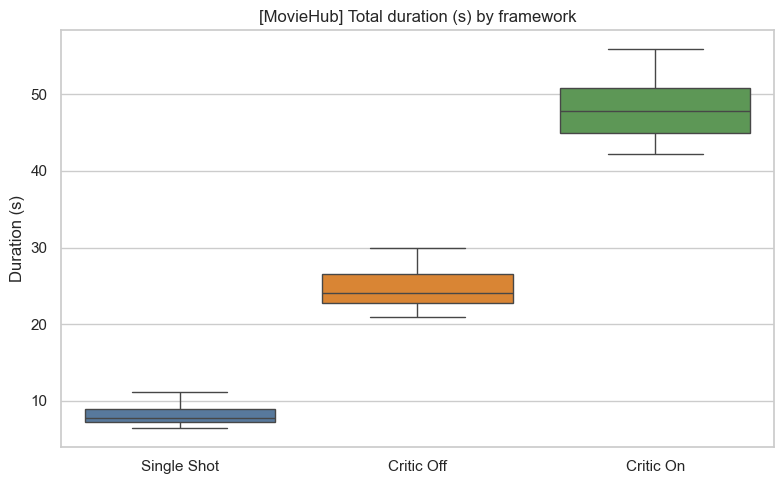

In [28]:
import warnings
warnings.filterwarnings("ignore")

# Total duration by framework.
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=runs_df, x="framework", y="total_duration_seconds",
    order=FRAMEWORK_ORDER, palette=FRAMEWORK_COLORS, ax=ax,
)
ax.set_title(title("Total duration (s) by framework"))
ax.set_xlabel("")
ax.set_ylabel("Duration (s)")
plt.tight_layout()
plt.show()


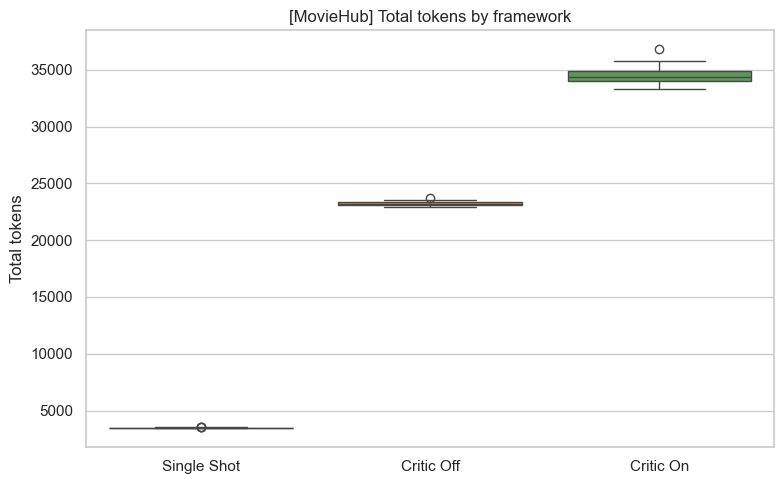

In [29]:
# Total tokens by framework.
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=runs_df, x="framework", y="total_tokens",
    order=FRAMEWORK_ORDER, palette=FRAMEWORK_COLORS, ax=ax,
)
ax.set_title(title("Total tokens by framework"))
ax.set_xlabel("")
ax.set_ylabel("Total tokens")
plt.tight_layout()
plt.show()


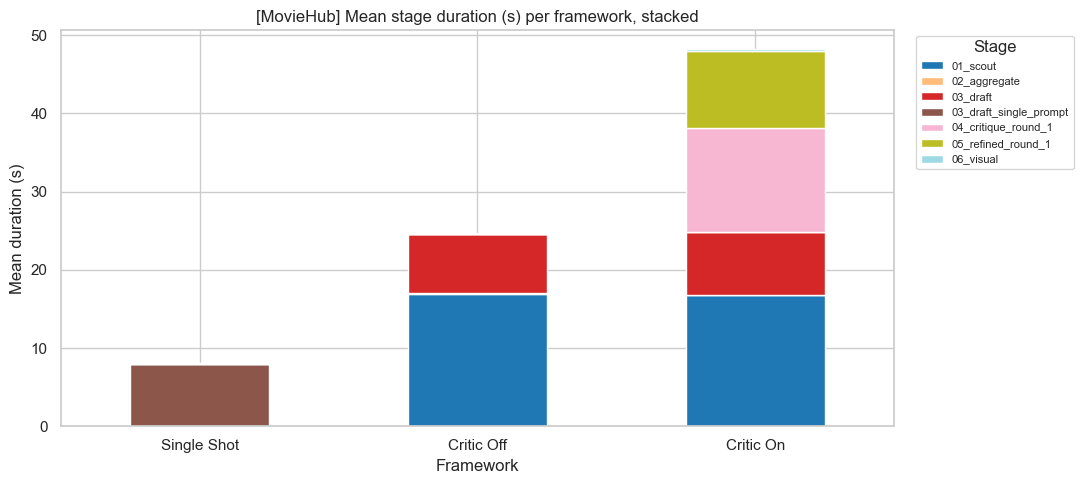

In [30]:
# Stacked-bar of mean stage duration per framework.
stage_mean = (
    stages_df.groupby(["framework", "stage"], as_index=False)["duration_seconds"].mean()
    .copy()
)
stage_pivot = stage_mean.pivot(index="framework", columns="stage", values="duration_seconds").fillna(0)
stage_pivot = stage_pivot.reindex(FRAMEWORK_ORDER)

fig, ax = plt.subplots(figsize=(11, 5))
stage_pivot.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_title(title("Mean stage duration (s) per framework, stacked"))
ax.set_ylabel("Mean duration (s)")
ax.set_xlabel("Framework")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Stage", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [31]:
# Tokens vs score: does spending more compute translate to a higher score?
fig = px.scatter(
    runs_df,
    x="total_tokens",
    y="overall_score",
    color="framework",
    category_orders={"framework": FRAMEWORK_ORDER},
    color_discrete_map=FRAMEWORK_COLORS,
    hover_data=["run_id", "core_overall_score", "total_duration_seconds"],
    trendline="ols",
    title=title("Cumulative score vs total_tokens (interactive)"),
)
fig.update_layout(height=500, yaxis_title="Cumulative score (%)")
fig.show()

In [38]:
# Pearson correlation: total_tokens vs overall_score, per framework and overall.
# Answer: No — more compute does NOT reliably translate to a higher score.
# Correlations are weak and inconsistent:
#   Single Shot  r = +0.31  (mild positive)
#   Critic Off   r = -0.39  (negative — more tokens, WORSE score)
#   Critic On    r = +0.30  (mild positive)
#   Overall      r = +0.22  (weak; driven by framework clusters, not within-framework trend)
for fw in FRAMEWORK_ORDER:
    sub = runs_df[runs_df["framework"] == fw]
    r = sub["total_tokens"].corr(sub["overall_score"])
    print(f"{fw:15s}  r = {r:+.3f}  (n={len(sub)})")
r_all = runs_df["total_tokens"].corr(runs_df["overall_score"])
print(f"{'All':15s}  r = {r_all:+.3f}  (n={len(runs_df)})")


Single Shot      r = +0.306  (n=28)
Critic Off       r = -0.394  (n=28)
Critic On        r = +0.303  (n=28)
All              r = +0.215  (n=84)


## 8. Cross-framework deltas

Pivot per `run_id` so each row carries every framework's score side-by-side. Then compute pairwise deltas to answer **&ldquo;does the critic actually help?&rdquo;** and **&ldquo;does multi-agent beat single-shot?&rdquo;**

In [36]:
pivot_metrics = ["overall_score", "core_overall_score", "total_duration_seconds", "total_tokens"]
wide = (
    runs_df.pivot_table(index="run_id", columns="framework", values=pivot_metrics)
    .copy()
)
# Flatten the MultiIndex: (metric, framework) -> "framework__metric"
wide.columns = [f"{fw}__{metric}" for metric, fw in wide.columns]
wide = wide.sort_index(axis=1)
wide.head()

,Critic Off__core_overall_score,Critic Off__overall_score,Critic Off__total_duration_seconds,Critic Off__total_tokens,Critic On__core_overall_score,Critic On__overall_score,Critic On__total_duration_seconds,Critic On__total_tokens,Single Shot__core_overall_score,Single Shot__overall_score,Single Shot__total_duration_seconds,Single Shot__total_tokens
run_id,,,,,,,,,,,,
20260421_002501_debug_compare,97.142857,57.65,24.857,23364.0,97.142857,57.65,46.851,34292.0,91.428571,51.76,8.620,3484.0
20260421_003008_debug_compare,97.142857,54.12,26.523,23422.0,97.142857,58.82,49.998,34524.0,91.428571,58.82,7.071,3479.0
20260421_003522_debug_compare,97.142857,55.29,25.614,23025.0,97.142857,54.12,51.909,35218.0,97.142857,64.71,10.372,3551.0
20260421_003948_debug_compare,97.142857,60.00,27.523,23734.0,91.428571,48.24,47.848,34036.0,91.428571,61.18,6.957,3492.0
20260421_004357_debug_compare,97.142857,58.82,29.902,23295.0,94.285714,57.65,46.411,33814.0,94.285714,54.12,7.582,3531.0


In [37]:
deltas = pd.DataFrame(index=wide.index)
for metric in ["overall_score", "core_overall_score"]:
    deltas[f"CriticOn_minus_CriticOff__{metric}"] = (
        wide[f"Critic On__{metric}"] - wide[f"Critic Off__{metric}"]
    )
    deltas[f"CriticOff_minus_SingleShot__{metric}"] = (
        wide[f"Critic Off__{metric}"] - wide[f"Single Shot__{metric}"]
    )
    deltas[f"CriticOn_minus_SingleShot__{metric}"] = (
        wide[f"Critic On__{metric}"] - wide[f"Single Shot__{metric}"]
    )

delta_summary = deltas.agg(["mean", "median", "std", "min", "max"]).round(2).T
delta_summary

,mean,median,std,min,max
CriticOn_minus_CriticOff__overall_score,4.33,2.36,7.50,-11.76,23.53
CriticOff_minus_SingleShot__overall_score,-0.29,0.00,5.71,-11.77,9.42
CriticOn_minus_SingleShot__overall_score,4.03,4.11,8.96,-12.94,23.53
CriticOn_minus_CriticOff__core_overall_score,-0.20,0.00,2.19,-5.71,5.71
CriticOff_minus_SingleShot__core_overall_score,3.57,2.86,3.26,-5.71,8.57
CriticOn_minus_SingleShot__core_overall_score,3.37,2.86,2.92,0.00,8.57


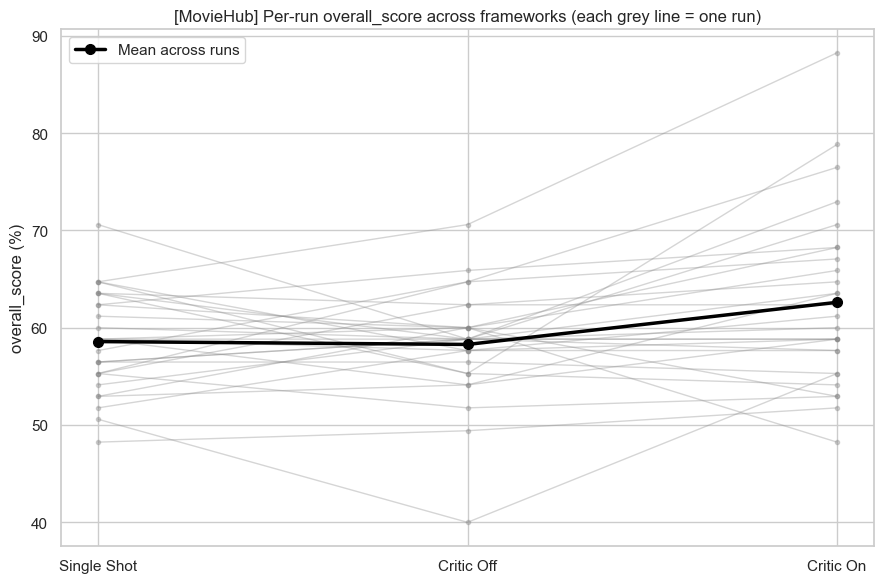

In [39]:
# Slope chart: one line per run_id, connecting its overall_score across the
# three frameworks. Lines that go UP from left to right mean the framework on
# the right scored higher on that run. The thick black line is the mean.
slope_df = (
    runs_df[["run_id", "framework", "overall_score"]]
    .copy()
)

fig, ax = plt.subplots(figsize=(9, 6))
for run_id, sub in slope_df.groupby("run_id"):
    sub = sub.set_index("framework").reindex(FRAMEWORK_ORDER)
    ax.plot(FRAMEWORK_ORDER, sub["overall_score"], color="#888", alpha=0.35, linewidth=1, marker="o", markersize=3)

mean_line = slope_df.groupby("framework")["overall_score"].mean().reindex(FRAMEWORK_ORDER)
ax.plot(FRAMEWORK_ORDER, mean_line.values, color="black", linewidth=2.5, marker="o", markersize=7, label="Mean across runs")

ax.set_title(title("Per-run overall_score across frameworks (each grey line = one run)"))
ax.set_ylabel("overall_score (%)")
ax.set_xlabel("")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

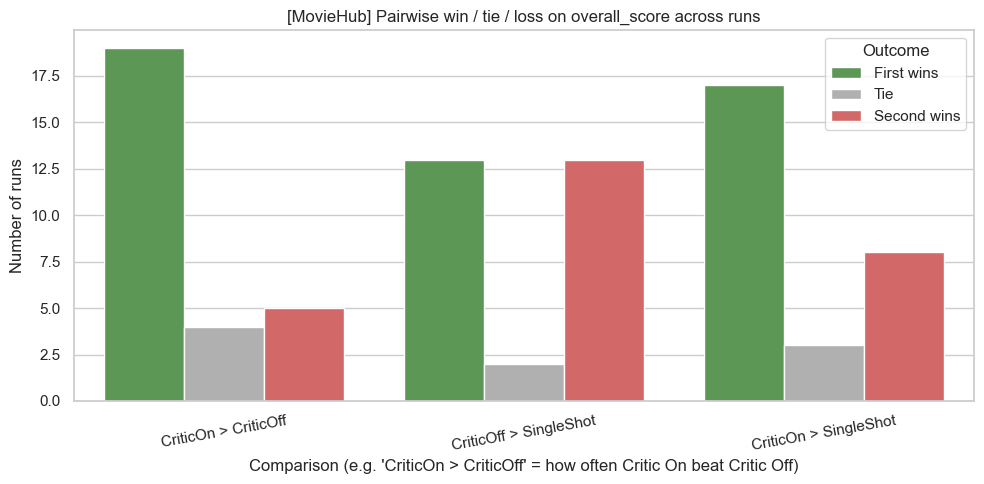

In [40]:
# Win / tie / loss bar chart for each pairwise comparison on overall_score.
# For each run, we ask: did the FIRST framework in the pair score higher,
# lower, or tie the SECOND framework? The bars show how often each outcome
# occurred across all runs.
def _wlt(series: pd.Series) -> dict[str, int]:
    return {
        "First wins": int((series > 0).sum()),
        "Tie":        int((series == 0).sum()),
        "Second wins":int((series < 0).sum()),
    }

wlt_rows = []
for col in deltas.filter(like="__overall_score").columns:
    label = col.replace("__overall_score", "").replace("_minus_", " > ")
    counts = _wlt(deltas[col].dropna())
    for outcome, n in counts.items():
        wlt_rows.append({"comparison": label, "outcome": outcome, "n_runs": n})
wlt_df = pd.DataFrame(wlt_rows).copy()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=wlt_df, x="comparison", y="n_runs", hue="outcome",
    hue_order=["First wins", "Tie", "Second wins"],
    palette={"First wins": "#54A24B", "Tie": "#B0B0B0", "Second wins": "#E45756"},
    ax=ax,
)
ax.set_title(title("Pairwise win / tie / loss on overall_score across runs"))
ax.set_ylabel("Number of runs")
ax.set_xlabel("Comparison (e.g. 'CriticOn > CriticOff' = how often Critic On beat Critic Off)")
ax.tick_params(axis="x", rotation=10)
ax.legend(title="Outcome", loc="best")
plt.tight_layout()
plt.show()

## 9. Export per-repo summary for cross-repo comparison

Writes a single `repo_summary_<REPO_NAME>.csv` row-per-framework into a shared `cross_repo_exports/` folder. The companion notebook [cross_repo_analysis.ipynb](cross_repo_analysis.ipynb) loads every file in that folder to compare repos side-by-side.

Re-run this cell after each new repo's analysis to keep the cross-repo dataset up to date.

In [42]:
# Build a per-(repo, framework) summary row capturing the headline stats.
# Schema is intentionally flat & long-lived so the cross-repo notebook can
# concat summaries from many repos without bespoke parsing.
CROSS_REPO_DIR = Path.cwd() / "cross_repo_exports"
CROSS_REPO_DIR.mkdir(exist_ok=True)

assert REPO_NAME, "Set REPO_NAME in the setup cell before exporting."

# Per-framework run-level stats (means/medians) on scores, latency, tokens.
run_agg = (
    runs_df.groupby("framework")
    .agg(
        n_runs=("run_id", "nunique"),
        core_score_mean=("core_overall_score", "mean"),
        core_score_median=("core_overall_score", "median"),
        overall_score_mean=("overall_score", "mean"),
        overall_score_median=("overall_score", "median"),
        duration_mean_s=("total_duration_seconds", "mean"),
        duration_median_s=("total_duration_seconds", "median"),
        input_tokens_mean=("input_tokens", "mean"),
        output_tokens_mean=("output_tokens", "mean"),
        total_tokens_mean=("total_tokens", "mean"),
    )
    .reindex(FRAMEWORK_ORDER)
)

# Per-framework variation-question quality stats.
var_agg = (
    questions_df[~questions_df["is_core"]]
    .groupby("framework")
    .agg(
        variation_pct_unanswered=("score", lambda s: (s == 0).mean() * 100),
        variation_pct_strong_answer=("score", lambda s: (s >= 4).mean() * 100),
    )
    .reindex(FRAMEWORK_ORDER)
)

repo_summary = (
    run_agg.join(var_agg)
    .round(3)
    .reset_index()
    .copy()
)
repo_summary.insert(0, "repo", REPO_NAME)

out_path = CROSS_REPO_DIR / f"repo_summary_{REPO_NAME}.csv"
repo_summary.to_csv(out_path, index=False)
# print(f"Wrote {out_path}")
repo_summary

,repo,framework,n_runs,core_score_mean,core_score_median,overall_score_mean,overall_score_median,duration_mean_s,duration_median_s,input_tokens_mean,output_tokens_mean,total_tokens_mean,variation_pct_unanswered,variation_pct_strong_answer
0,MovieHub,Single Shot,28,93.061,91.429,58.571,58.82,8.143,7.825,2973.000,526.536,3499.536,16.071,9.643
1,MovieHub,Critic Off,28,96.633,97.143,58.276,58.82,24.786,24.088,21414.714,1813.643,23228.357,22.500,11.786
2,MovieHub,Critic On,28,96.429,97.143,62.605,60.59,48.238,47.842,30851.714,3631.321,34483.036,18.214,19.286
